# Analysis tools

Now that we [know how to access data with `NanoEvents`](https://github.com/iris-hep/us-atlas-idap-training-2024/tree/main/PHYSLITE), let's go through some useful columnar analysis tools and idioms for building collections of results, namely, the eventual output of a `coffea` callable (or processor).
The most familiar type of output may be the histogram (one type of accumulator).

We'll just look at single files for the time being to keep things simple.

## Rapid review of what we've already seen

In [1]:
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import awkward as ak
from hist import Hist
from coffea.nanoevents import NanoEventsFactory, PHYSLITESchema
from coffea.analysis_tools import PackedSelection
import mplhep

PHYSLITESchema.warn_missing_crossrefs = False

In [2]:
from importlib.metadata import version

for package in ["numpy", "awkward", "uproot", "coffea"]:
    print(f"# {package}: v{version(package)}")

# numpy: v2.4.6
# awkward: v2.11.0
# uproot: v5.7.5
# coffea: v2026.7.0


In [3]:
# HZZ -> 4l sample

# local
# file_path = '/Users/iason/DAOD_PHYSLITE.38191712._000001.pool.root.1'

# stream
# file_path = "root://eospublic.cern.ch//eos/opendata/atlas/rucio/mc20_13TeV/DAOD_PHYSLITE.38191712._000001.pool.root.1"

# XCache
file_path = "root://xcache.af.uchicago.edu:1094//root://eospublic.cern.ch//eos/opendata/atlas/rucio/mc20_13TeV/DAOD_PHYSLITE.38191712._000001.pool.root.1"

There is lots of information in the files, but for this example we're only going to look at a few fields:
* Event information
* Electrons
* Muons
* Jets
* B-tagging

In [4]:
def filter_name(name):
    """
    Load only the properties/variables needed.
    """
    return name in (
        "EventInfoAuxDyn.mcEventWeights",
        "EventInfoAuxDyn.mcChannelNumber",
        #
        "AnalysisElectronsAuxDyn.pt",
        "AnalysisElectronsAuxDyn.eta",
        "AnalysisElectronsAuxDyn.phi",
        "AnalysisElectronsAuxDyn.m",
        "AnalysisElectronsAuxDyn.DFCommonElectronsLHLoose",
        "AnalysisElectronsAuxDyn.charge",
        #
        "AnalysisMuonsAuxDyn.pt",
        "AnalysisMuonsAuxDyn.eta",
        "AnalysisMuonsAuxDyn.phi",
        "AnalysisMuonsAuxDyn.m",
        "AnalysisMuonsAuxDyn.charge",
        "AnalysisMuonsAuxDyn.quality",
        #
        "AnalysisJetsAuxDyn.pt",
        "AnalysisJetsAuxDyn.eta",
        "AnalysisJetsAuxDyn.phi",
        "AnalysisJetsAuxDyn.m",
        #
        "BTagging_AntiKt4EMPFlowAuxDyn.DL1dv01_pb",
        "BTagging_AntiKt4EMPFlowAuxDyn.DL1dv01_pc",
        "BTagging_AntiKt4EMPFlowAuxDyn.DL1dv01_pu",
    )

There will be some warnings from `coffea`, but in this case they can be ignored.

In [5]:
warnings.filterwarnings(
    "ignore",
    message="Skipping ",
    category=UserWarning,
)

# coffea 2026.7 reads into *virtual arrays* by default (mode="virtual"): each
# branch stays on disk and is materialized only when first used. There is no
# dask task graph and no .compute() step -- results are produced eagerly as the
# arrays are touched. We pass mode explicitly here just to make that visible.
events = NanoEventsFactory.from_root(
    {file_path: "CollectionTree"},
    schemaclass=PHYSLITESchema,
    mode="virtual",
    iteritems_options=dict(filter_name=filter_name),
).events()

and we get the fields we requested

In [6]:
events.fields

['Electrons', 'Jets', 'BTagging_AntiKt4EMPFlow', 'EventInfo', 'Muons']

and the subfields that were requested for each field

In [7]:
for _field in events.fields:
    print(f"* {_field}: {events[_field].fields}")

* Electrons: ['pt', '_eventindex', 'eta', 'phi', 'm', 'charge', 'DFCommonElectronsLHLoose']
* Jets: ['pt', '_eventindex', 'eta', 'phi', 'm']
* BTagging_AntiKt4EMPFlow: ['DL1dv01_pu', '_eventindex', 'DL1dv01_pc', 'DL1dv01_pb']
* EventInfo: ['mcChannelNumber', 'mcEventWeights', '_eventindex']
* Muons: ['pt', '_eventindex', 'eta', 'phi', 'charge', 'quality', 'm']


## `PackedSelection`

This class can store several boolean arrays in a memory-efficient mannner and evaluate arbitrary combinations of boolean requirements in an CPU-efficient way. Supported inputs include 1D `numpy` or `awkward` arrays. This makes it a good tool to form analysis signal and control regions, and to implement cutflow or "N-1" plots.

Below we create a packed selection with some typical selections for a $Z$+jets study, to be used later to form same-sign and opposite-sign $ee$ and $\mu\mu$ event categories/regions.

We'll use [ATLAS open data electroweak boson simulation](https://opendata.cern.ch/record/80010) for this ( DOI:[10.7483/OPENDATA.ATLAS.K5SU.X65Y](http://doi.org/10.7483/OPENDATA.ATLAS.K5SU.X65Y)). Specifically `mc20_13TeV_MC_Sh_2211_Zee_maxHTpTV2_CVetoBVeto` and `mc20_13TeV_MC_Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto` samples.

In [8]:
# Zee

# local
# file_path = "/Users/iason/DAOD_PHYSLITE.37621317._000001.pool.root.1"

# stream
# file_path = "root://eospublic.cern.ch//eos/opendata/atlas/rucio/mc20_13TeV/DAOD_PHYSLITE.37621317._000001.pool.root.1"

# XCache
file_path = "root://xcache.af.uchicago.edu:1094//root://eospublic.cern.ch//eos/opendata/atlas/rucio/mc20_13TeV/DAOD_PHYSLITE.37621317._000001.pool.root.1"

In [9]:
events = NanoEventsFactory.from_root(
    {file_path: "CollectionTree"},
    schemaclass=PHYSLITESchema,
    mode="virtual",
    iteritems_options=dict(filter_name=filter_name),
).events()

In [10]:
selection = PackedSelection()

selection.add("two_electrons", ak.num(events.Electrons, axis=1) == 2)
selection.add("electrons_opposite_sign", ak.sum(events.Electrons.charge, axis=1) == 0)
selection.add("no_electrons", ak.num(events.Electrons, axis=1) == 0)

selection.add("two_muons", ak.num(events.Muons, axis=1) == 2)
selection.add("muons_opposite_sign", ak.sum(events.Muons.charge, axis=1) == 0)
selection.add("no_muons", ak.num(events.Muons, axis=1) == 0)


selection.add(
    "lead_pt_20",
    # assuming one of `two_electrons` or `two_muons` is imposed, this implies at least one is above threshold
    ak.any(events.Electrons.pt >= 20.0, axis=1)
    | ak.any(events.Muons.pt >= 20.0, axis=1),
)

print(selection.names)

['two_electrons', 'electrons_opposite_sign', 'no_electrons', 'two_muons', 'muons_opposite_sign', 'no_muons', 'lead_pt_20']


To evaluate a boolean mask (e.g. to filter events) we can use the `selection.all(*names)` function, which will compute the AND of all listed boolean selections

In [11]:
selection.all("two_electrons", "no_muons", "lead_pt_20")

array([False, False,  True, ...,  True, False, False], shape=(50000,))

We can also be more specific and require that a specific set of selections have a given value (with the unspecified ones allowed to be either `True` or `False`) using `selection.require`

In [12]:
selection.require(two_electrons=True, no_muons=True, electrons_opposite_sign=False)

array([False, False, False, ..., False, False, False], shape=(50000,))

Using the Python syntax for passing an arguments variable, we can easily implement a "N-1" style selection

In [13]:
all_cuts = {"two_electrons", "no_muons", "lead_pt_20"}
results = {}
for cut in all_cuts:
    n_events = ak.sum(selection.all(*(all_cuts - {cut})), axis=0)
    results[cut] = n_events

results["None"] = ak.sum(selection.all(*all_cuts), axis=0)

for cut, n_events in results.items():
    print(f"Events passing all cuts, ignoring '{cut}': {n_events}")

Events passing all cuts, ignoring 'no_muons': 23143
Events passing all cuts, ignoring 'two_electrons': 40008
Events passing all cuts, ignoring 'lead_pt_20': 21977
Events passing all cuts, ignoring 'None': 21977


Luckily coffea implements that for you. And also a "cutflow" selection via `selection.cutflow`

In [14]:
nminusone = selection.nminusone("two_electrons", "no_muons", "lead_pt_20")
nminusone.print()

N-1 selection stats:

Ignoring two_electrons       pass = 40008               all = 50000               -- eff = 80.0 %

Ignoring no_muons            pass = 23143               all = 50000               -- eff = 46.3 %

Ignoring lead_pt_20          pass = 21977               all = 50000               -- eff = 44.0 %

All cuts                     pass = 21977               all = 50000               -- eff = 44.0 %

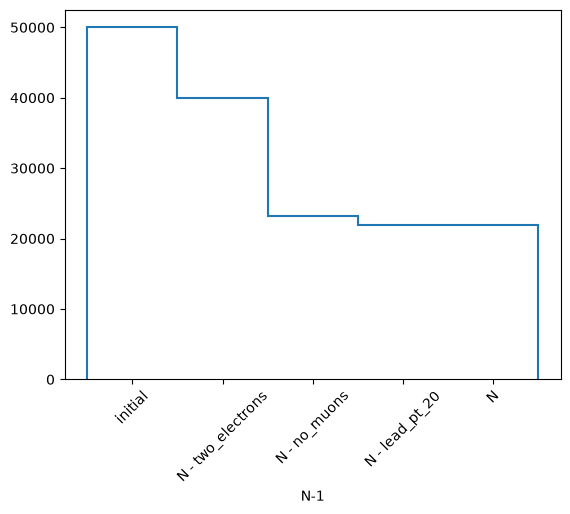

In [15]:
h, labels = nminusone.yieldhist()
h.plot()
plt.xticks(plt.gca().get_xticks(), labels, rotation=45)
plt.show()

### Weighted yields, cutflows, categorical splits, and N-1 variable plots

`PackedSelection` does more than boolean masks. Passing a `coffea.analysis_tools.Weights` object turns the N-1 and cutflow summaries into **weighted** yields, and the result objects (`NminusOne`, `Cutflow`) expose several conveniences we did not use above:

- `.print(weighted=True)` — weighted efficiency tables (with a `weightsmodifier` to pick a systematic variation),
- `.yieldhist(weighted=..., categorical=...)` — yield histograms, optionally split along a categorical axis (e.g. per channel or process),
- `.plot_vars({name: array}, ...)` — the distribution of chosen variables at each selection stage,

and `selection.cutflow(...)` is the sequential (cumulative) companion to `selection.nminusone(...)`. The cells below demonstrate each on the `Zee` sample.

In [ ]:
import numpy as np
import hist
from coffea.analysis_tools import Weights

# A Weights object accumulates per-event weights (and their systematic
# variations). Pass it to nminusone()/cutflow() to get *weighted* yields.
nev = len(events)
weights = Weights(nev)
# nominal generator weight (PHYSLITE stores per-event MC weights; take the first)
weights.add("genweight", ak.to_numpy(events.EventInfo.mcEventWeights[:, 0]))
# an illustrative flat lepton scale factor carrying an up/down systematic
weights.add(
    "lepton_sf",
    np.full(nev, 0.98),
    weightUp=np.full(nev, 0.99),
    weightDown=np.full(nev, 0.97),
)
print("total weight (first 3):", weights.weight()[:3])
print("registered systematics:", list(weights.variations))

# weighted N-1: hand the Weights object in, then print weighted efficiencies
nminusone_w = selection.nminusone("two_electrons", "no_muons", "lead_pt_20", weights=weights)
nminusone_w.print(weighted=True)

In [ ]:
# `cutflow` is the sequential companion to `nminusone`: cuts applied one after
# another. It is weighted the same way, and `weightsmodifier` selects a
# systematic variation registered on the Weights object.
cutflow = selection.cutflow("two_electrons", "electrons_opposite_sign", "lead_pt_20", weights=weights)
cutflow.print(weighted=True)

# yieldhist returns (per-cut hist, cumulative-cutflow hist, labels)
honecut, hcutflow, cut_labels = cutflow.yieldhist(weighted=True)

fig, ax = plt.subplots()
hcutflow.plot1d(ax=ax)
ax.set_xticks(range(len(cut_labels)))
ax.set_xticklabels(cut_labels, rotation=45, ha="right")
ax.set_ylabel("weighted events (cumulative)")
fig.tight_layout()

In [ ]:
# categorical: split the N-1 yields along an extra categorical axis.
# `categorical` is a dict {axis, values[, labels]}; `values` is one label per
# event (same length as the selections). Here we tag each event by channel.
n_e = ak.num(events.Electrons, axis=1)
n_mu = ak.num(events.Muons, axis=1)
channel = np.where(
    ak.to_numpy(n_e == 2), "ee", np.where(ak.to_numpy(n_mu == 2), "mumu", "other")
)

categorical = {
    "axis": hist.axis.StrCategory([], growth=True, name="channel", label="channel"),
    "values": channel,
}
h_cat, labels, catlabels = nminusone_w.yieldhist(weighted=True, categorical=categorical)

fig, ax = plt.subplots()
h_cat.plot1d(ax=ax, overlay="channel")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("weighted events")
ax.legend(title="channel")
fig.tight_layout()

In [ ]:
# plot_vars: the distribution of a per-object variable at each N-1 stage.
# The variable must be a per-object (jagged) array -- it is filled once per
# object and weighted by the (broadcast) event weight. plot_vars returns a list
# of histograms (one per variable) plus the stage labels.
var_hists, stage_labels = nminusone_w.plot_vars(
    {r"electron $\eta$": events.Electrons.eta},
    bins=[25],
    start=[-3.0],
    stop=[3.0],
    weighted=True,
)

fig, ax = plt.subplots()
var_hists[0].plot1d(ax=ax, overlay="nminusone")
ax.legend(title="N-1 stage", ncols=2, fontsize="small")
ax.set_ylabel("weighted electrons")
fig.tight_layout()

## Bringing it together

Let's build a callable function that books a few results:
* the sum of weights for the events processed (to use for later luminosity-normalizing the yields)
* a histogram of the dilepton invariant mass, with category axes for various selection regions of interest

In [16]:
events = NanoEventsFactory.from_root(
    {file_path: "CollectionTree"},
    schemaclass=PHYSLITESchema,
    mode="virtual",
    iteritems_options=dict(filter_name=filter_name),
).events()

In [17]:
events

<NanoEventsArray [{Jets: ??, ...}, ..., {Jets: ??, ...}] type='50000 * event'>

In [18]:
def results(events):
    selection = PackedSelection()

    selection.add("two_electrons", ak.num(events.Electrons, axis=1) == 2)
    selection.add(
        "electrons_opposite_sign", ak.sum(events.Electrons.charge, axis=1) == 0
    )
    selection.add("no_electrons", ak.num(events.Electrons, axis=1) == 0)

    selection.add("two_muons", ak.num(events.Muons, axis=1) == 2)
    selection.add("muons_opposite_sign", ak.sum(events.Muons.charge, axis=1) == 0)
    selection.add("no_muons", ak.num(events.Muons, axis=1) == 0)

    selection.add(
        "lead_pt_20",
        # assuming one of `two_electrons` or `two_muons` is imposed, this implies at least one is above threshold
        ak.any(events.Electrons.pt >= 20.0, axis=1)
        | ak.any(events.Muons.pt >= 20.0, axis=1),
    )

    regions = {
        "ee": {
            "two_electrons": True,
            "no_muons": True,
            "lead_pt_20": True,
            "electrons_opposite_sign": True,
        },
        "ee_same_sign": {
            "two_electrons": True,
            "no_muons": True,
            "lead_pt_20": True,
            "electrons_opposite_sign": False,
        },
        "mumu": {
            "two_muons": True,
            "no_electrons": True,
            "lead_pt_20": True,
            "muons_opposite_sign": True,
        },
        "mumu_same_sign": {
            "two_muons": True,
            "no_electrons": True,
            "lead_pt_20": True,
            "muons_opposite_sign": False,
        },
    }

    mass_hist = (
        Hist.new.StrCat(regions.keys(), name="region")
        .Reg(60, 60, 120, name="mass", label="$m_{ll}$ [GeV]")
        .Weight()
    )

    for region, cuts in regions.items():
        good_event = selection.require(**cuts)

        if region.startswith("ee"):
            leptons = events.Electrons[good_event]
        elif region.startswith("mumu"):
            # Hack for the time being given PHYSLITESchema needs fixing
            _muons = events.Muons[good_event]
            _muons["m"] = ak.zeros_like(_muons.pt)
            leptons = _muons
        lep1 = leptons[:, 0]
        lep2 = leptons[:, 1]
        mass = (lep1 + lep2).mass

        mass_hist.fill(
            region=region,
            mass=mass,
        )

    out = {
        "sumw": ak.sum(events.EventInfo.mcEventWeights, axis=0),
        "mass": mass_hist,
    }

    return out

So when we run `results(events)` we get back a plain `dict` of already-filled results (a sum of weights and a `hist` histogram). With the virtual-array backend the histograms are filled eagerly as the arrays are materialized — there is no lazy dask task graph and nothing to `.compute()`.

In [19]:
output = results(events)

output

{'sumw': <Array [6.96e+11, 2.24e+03, ..., 7.1e+11, 7.1e+11] type='319 * float32'>,
 'mass': Hist(
   StrCategory(['ee', 'ee_same_sign', 'mumu', 'mumu_same_sign'], name='region'),
   Regular(60, 60, 120, name='mass', label='$m_{ll}$ [GeV]'),
   storage=Weight()) # Sum: WeightedSum(value=25, variance=25) (WeightedSum(value=21984, variance=21984) with flow)}

Thanks to `hist` we can slo see nice Jupyter [`reprs`](https://docs.python.org/3/library/functions.html#repr) of the objects

In [20]:
output["mass"]

Hist(
  StrCategory(['ee', 'ee_same_sign', 'mumu', 'mumu_same_sign'], name='region'),
  Regular(60, 60, 120, name='mass', label='$m_{ll}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=25, variance=25) (WeightedSum(value=21984, variance=21984) with flow)

In [21]:
output["mass"][sum, :]

Hist(Regular(60, 60, 120, name='mass', label='$m_{ll}$ [GeV]'), storage=Weight()) # Sum: WeightedSum(value=25, variance=25) (WeightedSum(value=21984, variance=21984) with flow)

In [22]:
plot_dir = Path().cwd() / "plots"
plot_dir.mkdir(exist_ok=True)

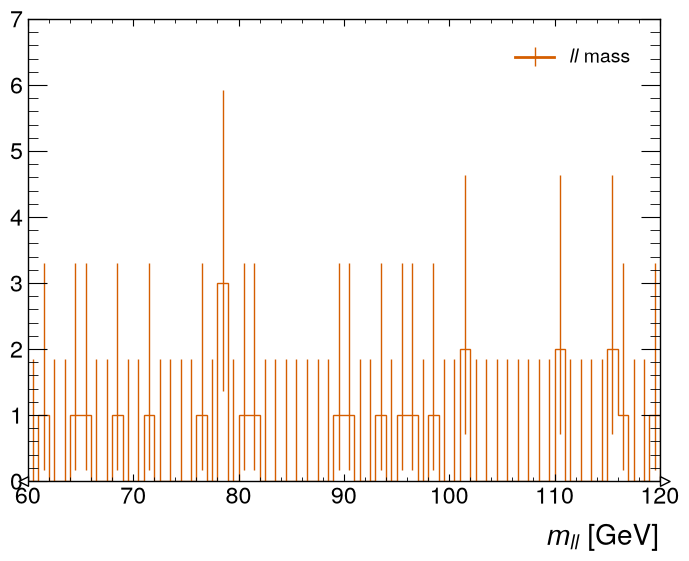

In [23]:
mplhep.style.use(mplhep.style.ATLAS)

fig, ax = plt.subplots()

output["mass"][sum, :].plot1d(ax=ax, label="$ll$ mass")
ax.legend()

fig.savefig(plot_dir / "ll_mass.png")

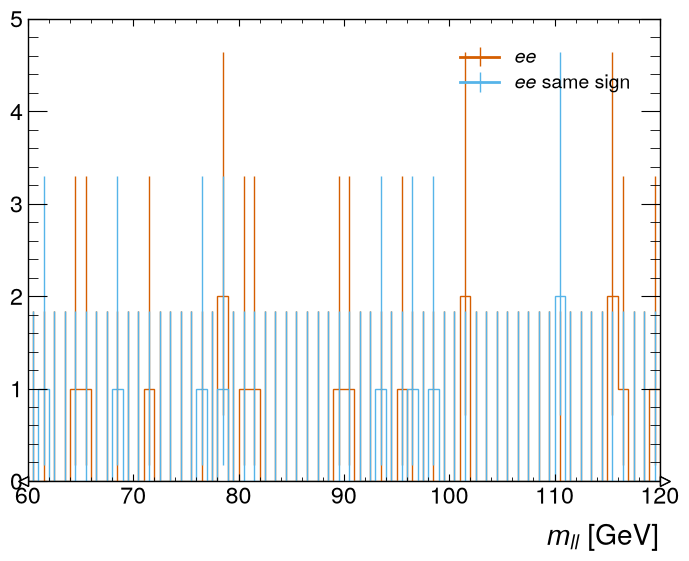

In [24]:
fig, ax = plt.subplots()

output["mass"]["ee", :].plot1d(ax=ax, label=r"$ee$")
output["mass"]["ee_same_sign", :].plot1d(ax=ax, label=r"$ee$ same sign")
ax.legend()

fig.savefig(plot_dir / "ee_mass.png")